In [1]:
# This Python 3 environment comes with many helpful analytics libraries installed
# It is defined by the kaggle/python Docker image: https://github.com/kaggle/docker-python
# For example, here's several helpful packages to load

import numpy as np # linear algebra
import pandas as pd # data processing, CSV file I/O (e.g. pd.read_csv)

# Input data files are available in the read-only "../input/" directory
# For example, running this (by clicking run or pressing Shift+Enter) will list all files under the input directory

import os
for dirname, _, filenames in os.walk('/kaggle/input'):
    for filename in filenames:
        print(os.path.join(dirname, filename))

# You can write up to 20GB to the current directory (/kaggle/working/) that gets preserved as output when you create a version using "Save & Run All" 
# You can also write temporary files to /kaggle/temp/, but they won't be saved outside of the current session

/kaggle/input/amazon-reco-ds/item_embeddings.npy
/kaggle/input/amazon-reco-ds/train_data_prepared.parquet
/kaggle/input/amazon-reco-ds/item_ids.npy
/kaggle/input/amazon-reco-ds/my_amazon_index.faiss
/kaggle/input/amazon-reco-ds/my_finetuned_model/config.json
/kaggle/input/amazon-reco-ds/my_finetuned_model/README.md
/kaggle/input/amazon-reco-ds/my_finetuned_model/tokenizer.json
/kaggle/input/amazon-reco-ds/my_finetuned_model/tokenizer_config.json
/kaggle/input/amazon-reco-ds/my_finetuned_model/sentence_bert_config.json
/kaggle/input/amazon-reco-ds/my_finetuned_model/config_sentence_transformers.json
/kaggle/input/amazon-reco-ds/my_finetuned_model/model.safetensors
/kaggle/input/amazon-reco-ds/my_finetuned_model/modules.json
/kaggle/input/amazon-reco-ds/my_finetuned_model/special_tokens_map.json
/kaggle/input/amazon-reco-ds/my_finetuned_model/vocab.txt
/kaggle/input/amazon-reco-ds/my_finetuned_model/1_Pooling/config.json
/kaggle/input/amazon-reco-ds/Amazon_Fashion/Amazon_Fashion.jsonl
/k

In [2]:
from kaggle_secrets import UserSecretsClient
user_secrets = UserSecretsClient()
secret_value_0 = user_secrets.get_secret("HF_TOKEN")

In [1]:
import pandas as pd
reviews = pd.read_json("/kaggle/input/amazon-reco-ds/Amazon_Fashion.jsonl", lines=True)
metadata= pd.read_json("/kaggle/input/amazon-reco-ds/meta_Amazon_Fashion.jsonl", lines=True)

In [2]:
reviews.head()

,rating,title,text,images,asin,parent_asin,user_id,timestamp,helpful_vote,verified_purchase
0,5,Pretty locket,I think this locket is really pretty. The insi...,[],B00LOPVX74,B00LOPVX74,AGBFYI2DDIKXC5Y4FARTYDTQBMFQ,2020-01-09 00:06:34.489,3,True
1,5,A,Great,[],B07B4JXK8D,B07B4JXK8D,AFQLNQNQYFWQZPJQZS6V3NZU4QBQ,2020-12-20 01:04:06.701,0,True
2,2,Two Stars,One of the stones fell out within the first 2 ...,[],B007ZSEQ4Q,B007ZSEQ4Q,AHITBJSS7KYUBVZPX7M2WJCOIVKQ,2015-05-23 01:33:48.000,3,True
3,1,Won’t buy again,Crappy socks. Money wasted. Bought to wear wit...,[],B07F2BTFS9,B07F2BTFS9,AFVNEEPDEIH5SPUN5BWC6NKL3WNQ,2018-12-31 20:57:27.095,2,True
4,5,I LOVE these glasses,I LOVE these glasses! They fit perfectly over...,[],B00PKRFU4O,B00XESJTDE,AHSPLDNW5OOUK2PLH7GXLACFBZNQ,2015-08-13 14:29:26.000,0,True


In [3]:
reviews.shape

(2500939, 10)

In [17]:
metadata.head(3)

,main_category,title,average_rating,rating_number,features,description,price,images,videos,store,categories,details,parent_asin,bought_together
0,AMAZON FASHION,YUEDGE 5 Pairs Men's Moisture Control Cushione...,4.6,16,[],[],NaN,[{'thumb': 'https://m.media-amazon.com/images/...,[],GiveGift,[],{'Package Dimensions': '10.31 x 8.5 x 1.73 inc...,B08BHN9PK5,NaN
1,AMAZON FASHION,DouBCQ Women's Palazzo Lounge Wide Leg Casual ...,4.1,7,"[Drawstring closure, Machine Wash]",[],NaN,[{'thumb': 'https://m.media-amazon.com/images/...,[],DouBCQ,[],{'Package Dimensions': '15 x 10.2 x 0.4 inches...,B08R39MRDW,NaN
2,AMAZON FASHION,Pastel by Vivienne Honey Vanilla Girls' Trapez...,4.3,11,"[Zipper closure, Hand Wash Only]",[],NaN,[{'thumb': 'https://m.media-amazon.com/images/...,[],Pastel by Vivienne,[],"{'Is Discontinued By Manufacturer': 'No', 'Pac...",B077KJHCJ4,NaN


In [7]:
metadata.shape

(826108, 14)

In [8]:
reviews.info()
print(reviews.isnull().sum())

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2500939 entries, 0 to 2500938
Data columns (total 10 columns):
 #   Column             Dtype         
---  ------             -----         
 0   rating             int64         
 1   title              object        
 2   text               object        
 3   images             object        
 4   asin               object        
 5   parent_asin        object        
 6   user_id            object        
 7   timestamp          datetime64[ns]
 8   helpful_vote       int64         
 9   verified_purchase  bool          
dtypes: bool(1), datetime64[ns](1), int64(2), object(6)
memory usage: 174.1+ MB
rating               0
title                0
text                 0
images               0
asin                 0
parent_asin          0
user_id              0
timestamp            0
helpful_vote         0
verified_purchase    0
dtype: int64


In [9]:
metadata.info()
print(metadata.isnull().sum())

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 826108 entries, 0 to 826107
Data columns (total 14 columns):
 #   Column           Non-Null Count   Dtype  
---  ------           --------------   -----  
 0   main_category    826108 non-null  object 
 1   title            826108 non-null  object 
 2   average_rating   826108 non-null  float64
 3   rating_number    826108 non-null  int64  
 4   features         826108 non-null  object 
 5   description      826108 non-null  object 
 6   price            50249 non-null   float64
 7   images           826108 non-null  object 
 8   videos           826108 non-null  object 
 9   store            799270 non-null  object 
 10  categories       826108 non-null  object 
 11  details          826108 non-null  object 
 12  parent_asin      826108 non-null  object 
 13  bought_together  0 non-null       float64
dtypes: float64(3), int64(1), object(10)
memory usage: 88.2+ MB
main_category           0
title                   0
average_rating       

In [10]:
print(metadata.duplicated(subset=['parent_asin']).sum())
print(reviews['rating'].value_counts())

0
rating
5    1426268
4     352327
1     303411
3     245471
2     173462
Name: count, dtype: int64


In [23]:
import pandas as pd
import numpy as np
import gc
import matplotlib.pyplot as plt
import seaborn as sns
import os

In [5]:
# 2. Drop "Useless" Columns
# Logic:
# - price: 94% Nulls (from your screenshot)
# - bought_together: 100% Nulls (from your screenshot)
# - main_category: Redundant (All are 'Amazon Fashion')
# - details, store, categories: High noise, low signal for semantic retrieval
# - helpful_vote: Not used for "matching", only for quality filtering (optional)

meta_cols_to_drop = ['price', 'bought_together', 'main_category', 'store', 'categories', 'details']
review_cols_to_drop = ['helpful_vote', 'asin']
metadata.drop(columns=meta_cols_to_drop, inplace=True, errors='ignore')
reviews.drop(columns=review_cols_to_drop, inplace=True, errors='ignore')

In [21]:
reviews.head()

,rating,title,text,images,parent_asin,user_id,timestamp,verified_purchase
0,5,Pretty locket,I think this locket is really pretty. The insi...,[],B00LOPVX74,AGBFYI2DDIKXC5Y4FARTYDTQBMFQ,2020-01-09 00:06:34.489,True
1,5,A,Great,[],B07B4JXK8D,AFQLNQNQYFWQZPJQZS6V3NZU4QBQ,2020-12-20 01:04:06.701,True
2,2,Two Stars,One of the stones fell out within the first 2 ...,[],B007ZSEQ4Q,AHITBJSS7KYUBVZPX7M2WJCOIVKQ,2015-05-23 01:33:48.000,True
3,1,Won’t buy again,Crappy socks. Money wasted. Bought to wear wit...,[],B07F2BTFS9,AFVNEEPDEIH5SPUN5BWC6NKL3WNQ,2018-12-31 20:57:27.095,True
4,5,I LOVE these glasses,I LOVE these glasses! They fit perfectly over...,[],B00XESJTDE,AHSPLDNW5OOUK2PLH7GXLACFBZNQ,2015-08-13 14:29:26.000,True


In [22]:
metadata.head()

,title,average_rating,rating_number,features,description,images,videos,parent_asin
0,YUEDGE 5 Pairs Men's Moisture Control Cushione...,4.6,16,[],[],[{'thumb': 'https://m.media-amazon.com/images/...,[],B08BHN9PK5
1,DouBCQ Women's Palazzo Lounge Wide Leg Casual ...,4.1,7,"[Drawstring closure, Machine Wash]",[],[{'thumb': 'https://m.media-amazon.com/images/...,[],B08R39MRDW
2,Pastel by Vivienne Honey Vanilla Girls' Trapez...,4.3,11,"[Zipper closure, Hand Wash Only]",[],[{'thumb': 'https://m.media-amazon.com/images/...,[],B077KJHCJ4
3,Mento Streamtail,2.0,1,"[Thermoplastic Rubber sole, High Density Premi...",[Slip on the Women's Mento and you're ready to...,[{'thumb': 'https://m.media-amazon.com/images/...,[],B0811M2JG9
4,RONNOX Women's 3-Pairs Bright Colored Calf Com...,4.3,3032,"[Pull On closure, Size Guide: ""S"" fits calf 10...",[Ronnox Calf Sleeves - Allowing Your Body to P...,[{'thumb': 'https://m.media-amazon.com/images/...,[{'title': 'HONEST Review: RONNOX Women's 3-Pa...,B07SB2892S


In [6]:
# 3. Clean Text Columns (Fill NaNs)
# We fill visuals with empty lists/strings so the code doesn't crash later
metadata.fillna({'title': '', 'features': '', 'description': '', 'images': ''}, inplace=True)
reviews.fillna({'text': '', 'title': '', 'images': ''}, inplace=True)

In [24]:
reviews.head()

,rating,title,text,images,parent_asin,user_id,timestamp,verified_purchase
0,5,Pretty locket,I think this locket is really pretty. The insi...,[],B00LOPVX74,AGBFYI2DDIKXC5Y4FARTYDTQBMFQ,2020-01-09 00:06:34.489,True
1,5,A,Great,[],B07B4JXK8D,AFQLNQNQYFWQZPJQZS6V3NZU4QBQ,2020-12-20 01:04:06.701,True
2,2,Two Stars,One of the stones fell out within the first 2 ...,[],B007ZSEQ4Q,AHITBJSS7KYUBVZPX7M2WJCOIVKQ,2015-05-23 01:33:48.000,True
3,1,Won’t buy again,Crappy socks. Money wasted. Bought to wear wit...,[],B07F2BTFS9,AFVNEEPDEIH5SPUN5BWC6NKL3WNQ,2018-12-31 20:57:27.095,True
4,5,I LOVE these glasses,I LOVE these glasses! They fit perfectly over...,[],B00XESJTDE,AHSPLDNW5OOUK2PLH7GXLACFBZNQ,2015-08-13 14:29:26.000,True


In [25]:
metadata.head()

,title,average_rating,rating_number,features,description,images,videos,parent_asin
0,YUEDGE 5 Pairs Men's Moisture Control Cushione...,4.6,16,[],[],[{'thumb': 'https://m.media-amazon.com/images/...,[],B08BHN9PK5
1,DouBCQ Women's Palazzo Lounge Wide Leg Casual ...,4.1,7,"[Drawstring closure, Machine Wash]",[],[{'thumb': 'https://m.media-amazon.com/images/...,[],B08R39MRDW
2,Pastel by Vivienne Honey Vanilla Girls' Trapez...,4.3,11,"[Zipper closure, Hand Wash Only]",[],[{'thumb': 'https://m.media-amazon.com/images/...,[],B077KJHCJ4
3,Mento Streamtail,2.0,1,"[Thermoplastic Rubber sole, High Density Premi...",[Slip on the Women's Mento and you're ready to...,[{'thumb': 'https://m.media-amazon.com/images/...,[],B0811M2JG9
4,RONNOX Women's 3-Pairs Bright Colored Calf Com...,4.3,3032,"[Pull On closure, Size Guide: ""S"" fits calf 10...",[Ronnox Calf Sleeves - Allowing Your Body to P...,[{'thumb': 'https://m.media-amazon.com/images/...,[{'title': 'HONEST Review: RONNOX Women's 3-Pa...,B07SB2892S


In [7]:
# 4. Standardize IDs (Strip Whitespace)
reviews['parent_asin'] = reviews['parent_asin'].astype(str).str.strip()
metadata['parent_asin'] = metadata['parent_asin'].astype(str).str.strip()

In [8]:
# 5. Drop Duplicates (Critical for RecSys)
# A user might review the same parent item twice (e.g. bought size M then size L).
# We keep the most recent one to avoid "leaking" the future.
if 'timestamp' in reviews.columns:
    reviews.sort_values('timestamp', inplace=True)
    reviews.drop_duplicates(subset=['user_id', 'parent_asin'], keep='last', inplace=True)

In [9]:
gc.collect()

32

In [10]:
list(reviews.columns)

['rating',
 'title',
 'text',
 'images',
 'parent_asin',
 'user_id',
 'timestamp',
 'verified_purchase']

In [11]:
list(metadata.columns)

['title',
 'average_rating',
 'rating_number',
 'features',
 'description',
 'images',
 'videos',
 'parent_asin']

/tmp/ipykernel_55/699833102.py:8: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=top_titles.index, y=top_titles.values, palette='viridis')


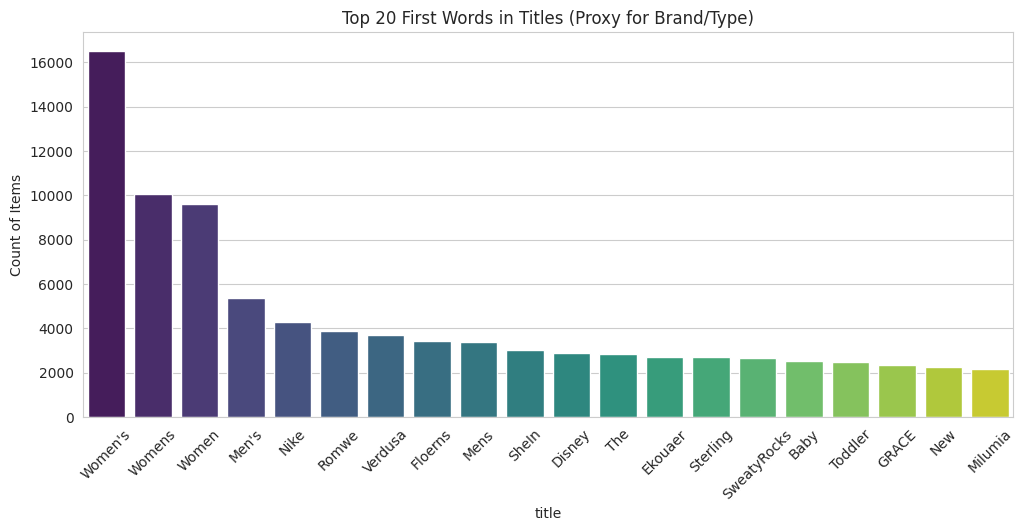

In [40]:
# --- 1. Top Brands/Categories Analysis ---
plt.figure(figsize=(12, 5))
top_titles = metadata['title'].apply(
    lambda x: x.split()[0] if (isinstance(x, str) and x.strip()) else 'Unknown'
).value_counts().head(20)

sns.barplot(x=top_titles.index, y=top_titles.values, palette='viridis')
plt.title('Top 20 First Words in Titles (Proxy for Brand/Type)')
plt.xticks(rotation=45)
plt.ylabel('Count of Items')
plt.show()

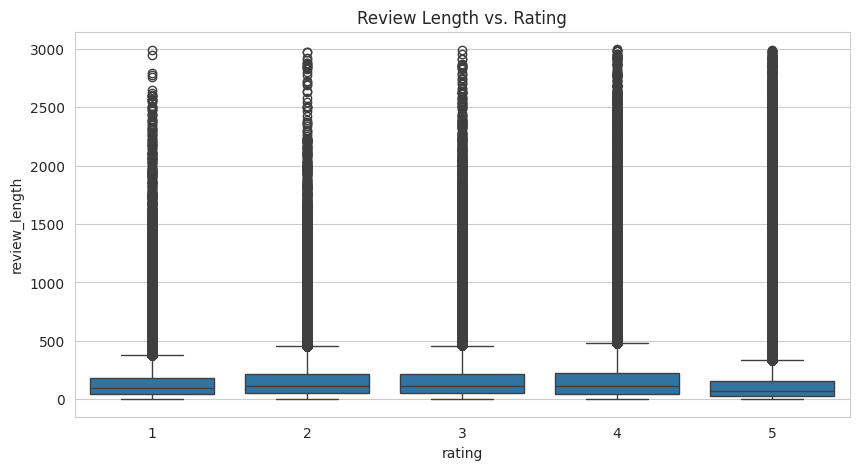

In [49]:
# --- 2. Price vs. Rating Correlation (If Price existed) ---
# we check Rating vs. Length of Review
# Hypothesis: Do people write longer reviews when they are angry (1 star) or happy (5 stars)?
reviews['review_length'] = reviews['text'].str.len()
plt.figure(figsize=(10, 5))
sns.boxplot(x='rating', y='review_length', data=reviews[reviews['review_length'] < 3000]) # Limit outlier
plt.title('Review Length vs. Rating')
plt.show()

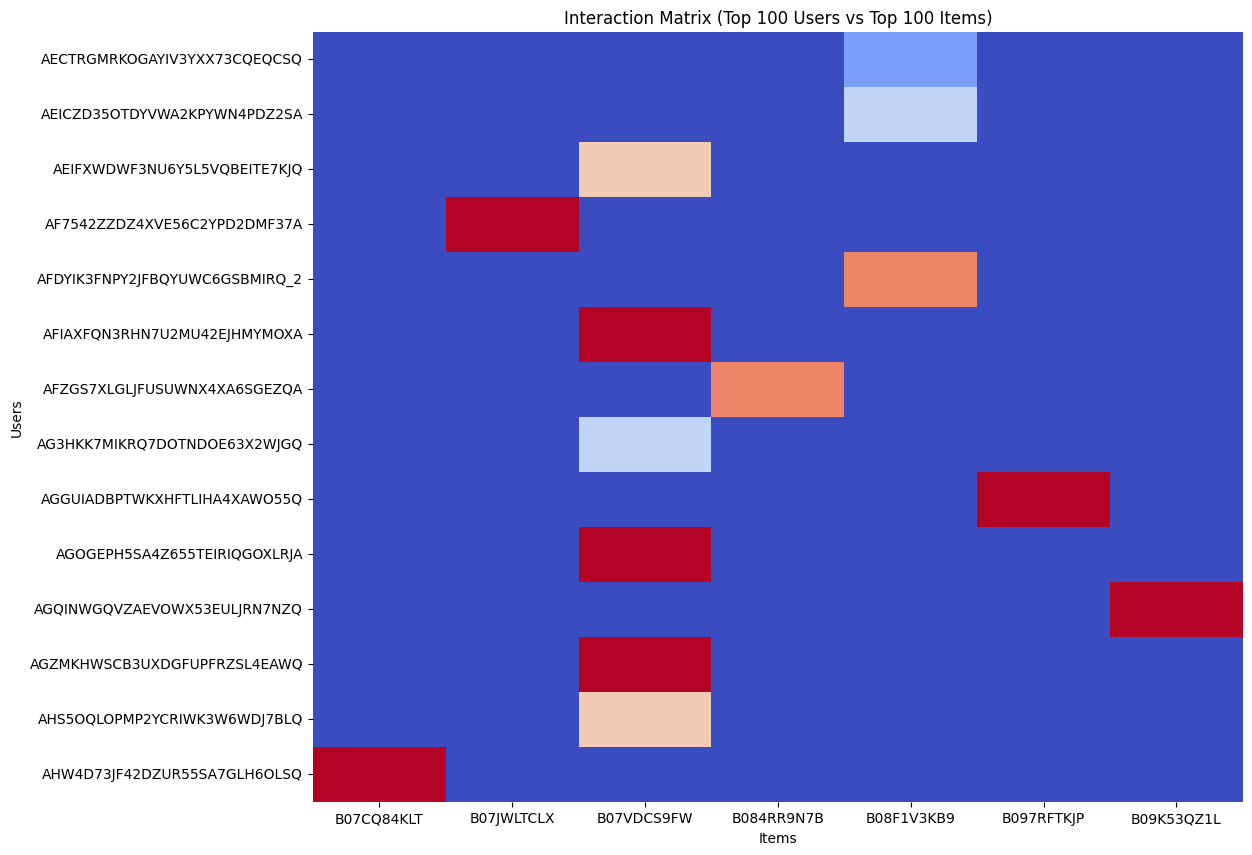

In [12]:
# --- 3. User-Item Interaction Matrix Sparsity Heatmap ---
# We can't plot the whole matrix (too big), but we can plot the top 100 users x top 100 items
# This visually shows "Clusters" of purchases.
# 0 (No interaction) to Dark Blue and 5 (High Rating) to Dark Red.
top_users = reviews['user_id'].value_counts().head(100).index
top_items = reviews['parent_asin'].value_counts().head(100).index

pivot_matrix = reviews[
    (reviews['user_id'].isin(top_users)) & 
    (reviews['parent_asin'].isin(top_items))
].pivot_table(index='user_id', columns='parent_asin', values='rating', fill_value=0)

plt.figure(figsize=(12, 10))
sns.heatmap(pivot_matrix, cmap='coolwarm', cbar=False)
plt.title('Interaction Matrix (Top 100 Users vs Top 100 Items)')
plt.xlabel('Items')
plt.ylabel('Users')
plt.show()


* 95%+ of the image is Dark Blue (Zero).[ **SPARSE** ]Meaning: Even though we selected the most active users and most popular items, most of these top users still haven't bought most of the top items.Constraint: This visually proves why "Collaborative Filtering" (finding users who bought the exact same things) is difficult. The overlap is tiny.

* The Red/Orange squares represent actual purchases (Ratings 4 or 5). [ **CLUSTERS** ]Notice they are not randomly scattered like static noise. They form vertical patterns.Vertical Pattern: You can see specific columns (Items) that have multiple red blocks. These are "Super Popular" items that multiple top users agreed on.

*Standard models look for overlapping Red Blocks to say "User A is like User B." Because there are so few overlaps (mostly Blue), standard models fail.*

**Your Model:** It doesn't just look at the Red Blocks. It reads the Text associated with the item. Even if User A and User B never bought the same item (no Red overlap), if they both bought items with the text "Running Shoe," your model connects them. This "fills in the blue gaps" with semantic understanding.

In [24]:
metadata.head()

,title,average_rating,rating_number,features,description,images,videos,parent_asin
0,YUEDGE 5 Pairs Men's Moisture Control Cushione...,4.6,16,[],[],[{'thumb': 'https://m.media-amazon.com/images/...,[],B08BHN9PK5
1,DouBCQ Women's Palazzo Lounge Wide Leg Casual ...,4.1,7,"[Drawstring closure, Machine Wash]",[],[{'thumb': 'https://m.media-amazon.com/images/...,[],B08R39MRDW
2,Pastel by Vivienne Honey Vanilla Girls' Trapez...,4.3,11,"[Zipper closure, Hand Wash Only]",[],[{'thumb': 'https://m.media-amazon.com/images/...,[],B077KJHCJ4
3,Mento Streamtail,2.0,1,"[Thermoplastic Rubber sole, High Density Premi...",[Slip on the Women's Mento and you're ready to...,[{'thumb': 'https://m.media-amazon.com/images/...,[],B0811M2JG9
4,RONNOX Women's 3-Pairs Bright Colored Calf Com...,4.3,3032,"[Pull On closure, Size Guide: ""S"" fits calf 10...",[Ronnox Calf Sleeves - Allowing Your Body to P...,[{'thumb': 'https://m.media-amazon.com/images/...,[{'title': 'HONEST Review: RONNOX Women's 3-Pa...,B07SB2892S


In [25]:
# --- 2. Create 'doc_text' (Item Side) ---
# Combine Title + Features + Description
metadata['doc_text'] = (
    metadata['title'] + " [SEP] " + 
    metadata['features'].astype(str) + " [SEP] " +
    metadata['description'].astype(str)
).str.slice(0, 1200) # Save RAM as model context is 384 tokens means 1200-1500 characters, so after all is truncated so no need to store as well for CPU burden.

# Create lookup dictionary
item_lookup = dict(zip(metadata['parent_asin'], metadata['doc_text']))

In [26]:
metadata.head()

,title,average_rating,rating_number,features,description,images,videos,parent_asin,doc_text
0,YUEDGE 5 Pairs Men's Moisture Control Cushione...,4.6,16,[],[],[{'thumb': 'https://m.media-amazon.com/images/...,[],B08BHN9PK5,YUEDGE 5 Pairs Men's Moisture Control Cushione...
1,DouBCQ Women's Palazzo Lounge Wide Leg Casual ...,4.1,7,"[Drawstring closure, Machine Wash]",[],[{'thumb': 'https://m.media-amazon.com/images/...,[],B08R39MRDW,DouBCQ Women's Palazzo Lounge Wide Leg Casual ...
2,Pastel by Vivienne Honey Vanilla Girls' Trapez...,4.3,11,"[Zipper closure, Hand Wash Only]",[],[{'thumb': 'https://m.media-amazon.com/images/...,[],B077KJHCJ4,Pastel by Vivienne Honey Vanilla Girls' Trapez...
3,Mento Streamtail,2.0,1,"[Thermoplastic Rubber sole, High Density Premi...",[Slip on the Women's Mento and you're ready to...,[{'thumb': 'https://m.media-amazon.com/images/...,[],B0811M2JG9,Mento Streamtail [SEP] ['Thermoplastic Rubber ...
4,RONNOX Women's 3-Pairs Bright Colored Calf Com...,4.3,3032,"[Pull On closure, Size Guide: ""S"" fits calf 10...",[Ronnox Calf Sleeves - Allowing Your Body to P...,[{'thumb': 'https://m.media-amazon.com/images/...,[{'title': 'HONEST Review: RONNOX Women's 3-Pa...,B07SB2892S,RONNOX Women's 3-Pairs Bright Colored Calf Com...


In [27]:
reviews.head()

,rating,title,text,images,parent_asin,user_id,timestamp,verified_purchase
2303159,5,Rock On!,"I just recently purchased this glider, and I c...",[],B000059XQJ,AHKL6HJYEUNZI2OHEHROQTCGTELA,2002-05-07 01:51:28,False
514045,5,What a Bargain!,These are my son's favorite bedtime jammies. ...,[],B00005RCSK,AGKEIHAHRXEOXCUVQVOWECIA4L6A,2002-07-23 20:54:50,False
522897,5,Update,"I wrote a review earlier, and I just wanted to...",[],B000059XR4,AG2WXS3EDCF55RFAB5UI6RBFF6MA,2002-09-10 13:38:24,True
256651,5,"Long-lasting, soft, and high quality",We received theses gowns as a gift for our son...,[],B00005RCSK,AFMMNPUBZIB6F2TVT7FNHE3GDAQQ,2002-10-05 07:53:31,False
2288568,5,"Good fit, durable, cute","Best weave, fit, looks, and washability of eve...",[],B00005RCS7,AFCOP7KD76MQE4OUJ4KOB3WF3S6A,2002-11-02 12:25:58,False


In [39]:
df = reviews[reviews['rating'] >= 4.0].copy()
df.shape
df.head()

,rating,title,text,images,parent_asin,user_id,timestamp,verified_purchase
2303159,5,Rock On!,"I just recently purchased this glider, and I c...",[],B000059XQJ,AHKL6HJYEUNZI2OHEHROQTCGTELA,2002-05-07 01:51:28,False
514045,5,What a Bargain!,These are my son's favorite bedtime jammies. ...,[],B00005RCSK,AGKEIHAHRXEOXCUVQVOWECIA4L6A,2002-07-23 20:54:50,False
522897,5,Update,"I wrote a review earlier, and I just wanted to...",[],B000059XR4,AG2WXS3EDCF55RFAB5UI6RBFF6MA,2002-09-10 13:38:24,True
256651,5,"Long-lasting, soft, and high quality",We received theses gowns as a gift for our son...,[],B00005RCSK,AFMMNPUBZIB6F2TVT7FNHE3GDAQQ,2002-10-05 07:53:31,False
2288568,5,"Good fit, durable, cute","Best weave, fit, looks, and washability of eve...",[],B00005RCS7,AFCOP7KD76MQE4OUJ4KOB3WF3S6A,2002-11-02 12:25:58,False


In [29]:
# --- 3. Create 'query_text' (User Side) ---
# Filter for positive reviews & sort by time
# df = reviews[reviews['rating'] >= 4.0].copy() # We want to model User Preference, not just User Activity

if 'timestamp' in df.columns:
    df['timestamp'] = pd.to_datetime(df['timestamp'])
    df.sort_values('timestamp', inplace=True) # old to new arrange

# Group by User: Combine last 5 reviews
user_history = df.groupby('user_id')['text'].apply(
    lambda x: " [SEP] ".join(x.tail(5).astype(str))
).to_dict()

In [40]:
# user_history
first_five = dict(list(user_history.items())[:5])
first_five

{'AE22236AFRRSMQIKGG7TPTB75QEA': 'Looks great, fits great.  Handles what life can throw at it.',
 'AE222GY2VH7MEWI4N5AHPXB5CP5A': 'These cute little earrings look like the real thing. Great value. Perfect for casual wear because the size is believable and the quality is there. They are really fine for all occasions.',
 'AE222H3FGXWLHRFUMGMS2RR57NDQ': 'Looked like a nice shirt ... but way too small.  Returned it.',
 'AE222SFRFOAFCUJ3DKA3MVPDP3IA': 'classy. Great protective case too!',
 'AE2233IKA2327CVE7WFSJVHDTPOA': 'Love the shirt, will buy more at this price, cheaper than at my golf club.'}

In [41]:
# --- 4. Merge & Save ---
# Our input is pair. We only need the pairs that exist in our filtered reviews
train_df = df[['user_id', 'parent_asin']].copy()

# Map the text columns
train_df['query_text'] = train_df['user_id'].map(user_history)
train_df['doc_text'] = train_df['parent_asin'].map(item_lookup)

In [42]:
train_df

,user_id,parent_asin,query_text,doc_text
2303159,AHKL6HJYEUNZI2OHEHROQTCGTELA,B000059XQJ,"I just recently purchased this glider, and I c...",Glider Rocker - Natural with Blue [SEP] [] [SE...
514045,AGKEIHAHRXEOXCUVQVOWECIA4L6A,B00005RCSK,These are my son's favorite bedtime jammies. ...,Carter's 2 Pack Gown - Blue (Newborn Size) [SE...
522897,AG2WXS3EDCF55RFAB5UI6RBFF6MA,B000059XR4,"I wrote a review earlier, and I just wanted to...",Glider Rocker - Stripped Denim [SEP] [] [SEP] ...
256651,AFMMNPUBZIB6F2TVT7FNHE3GDAQQ,B00005RCSK,We received theses gowns as a gift for our son...,Carter's 2 Pack Gown - Blue (Newborn Size) [SE...
2288568,AFCOP7KD76MQE4OUJ4KOB3WF3S6A,B00005RCS7,"Best weave, fit, looks, and washability of eve...",Carter's White 3 Pack Bodysuit - Small [SEP] [...
...,...,...,...,...
2473351,AGHCXZCNSD4O5Y4D2IYOLW66OKTA,B0BYCZ2W78,I purchased these shirts based on the reviews ...,DEVOPS Men's 2 Pack UPF 50+ Sun Protection Lon...
2492600,AHMQMS4372NVCHIEHFDD6XFSWQXQ,B09QFJGKM5,It helps quite a bit to have a sock aid.,Copper Fit Energy Unisex Easy-On/Easy-Off Knee...
2491862,AGHHAFJB6Z2XR4DR5RAUDSRRBS2Q,B0BD5VDV7K,Great product will wear it to Rick Springfield...,Ro Rox Adam Men’s Marching Band Drummer Milita...
2489861,AFGHKKOCZBLRK4RUKRWCUQC4V76Q,B0BCBR7HX1,"These shoes were perfect, comfortable and easy...",TruFox Knee High Platform Boots Chunky Heel Pu...


In [44]:
train_df.isnull().sum()

user_id        0
parent_asin    0
query_text     0
doc_text       0
dtype: int64

In [ ]:
# Drop missing (items not in metadata) - if not for testing
train_df.dropna(subset=['query_text', 'doc_text'], inplace=True)

In [45]:
# Select FINAL Data
final_train_data = train_df[['query_text', 'doc_text']]

In [48]:
final_train_data.head()

,query_text,doc_text
2303159,"I just recently purchased this glider, and I c...",Glider Rocker - Natural with Blue [SEP] [] [SE...
514045,These are my son's favorite bedtime jammies. ...,Carter's 2 Pack Gown - Blue (Newborn Size) [SE...
522897,"I wrote a review earlier, and I just wanted to...",Glider Rocker - Stripped Denim [SEP] [] [SEP] ...
256651,We received theses gowns as a gift for our son...,Carter's 2 Pack Gown - Blue (Newborn Size) [SE...
2288568,"Best weave, fit, looks, and washability of eve...",Carter's White 3 Pack Bodysuit - Small [SEP] [...


In [50]:
# Save to disk (Parquet is faster/safer than CSV for text)
save_path = "train_data_prepared.parquet"
final_train_data.to_parquet(save_path, index=False)

In [53]:
final_train_data.head()

,query_text,doc_text
2303159,"I just recently purchased this glider, and I c...",Glider Rocker - Natural with Blue [SEP] [] [SE...
514045,These are my son's favorite bedtime jammies. ...,Carter's 2 Pack Gown - Blue (Newborn Size) [SE...
522897,"I wrote a review earlier, and I just wanted to...",Glider Rocker - Stripped Denim [SEP] [] [SEP] ...
256651,We received theses gowns as a gift for our son...,Carter's 2 Pack Gown - Blue (Newborn Size) [SE...
2288568,"Best weave, fit, looks, and washability of eve...",Carter's White 3 Pack Bodysuit - Small [SEP] [...


In [55]:
from sentence_transformers import SentenceTransformer

model = SentenceTransformer("sentence-transformers/all-mpnet-base-v2")

In [56]:
# Testing LLM
sentences = [
    "That is a happy person",
    "That is a happy dog",
    "That is a very happy person",
    "Today is a sunny day"
]
embeddings = model.encode(sentences)
similarities = model.similarity(embeddings, embeddings)
# print(similarities.shape)
similarities
# [4, 4]

tensor([[1.0000, 0.7640, 0.9666, 0.3148],
        [0.7640, 1.0000, 0.7499, 0.3118],
        [0.9666, 0.7499, 1.0000, 0.3226],
        [0.3148, 0.3118, 0.3226, 1.0000]])

In [4]:
!pip install faiss-cpu

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 23.8/23.8 MB 94.0 MB/s eta 0:00:00:00:0100:01


In [11]:
# Install if not already installed (uncomment if running in a new Kaggle session)
# !pip install sentence-transformers

import os
import pandas as pd
import numpy as np
from sentence_transformers import SentenceTransformer, InputExample, losses
from torch.utils.data import DataLoader
from IPython.display import display, HTML
from tqdm.notebook import tqdm
import torch
import faiss
import json
import gc

In [4]:
# --- 1. SETTINGS & SAFETY SWITCHES ---
os.environ["WANDB_DISABLED"] = "true"          
os.environ["TOKENIZERS_PARALLELISM"] = "false" 
os.environ["CUDA_VISIBLE_DEVICES"] = "0"       
os.environ["PYTORCH_CUDA_ALLOC_CONF"] = "expandable_segments:True" # Helps fragmentation

In [11]:
# --- 1. Configuration ---
MODEL_NAME = 'sentence-transformers/all-mpnet-base-v2'
DATA_PATH = "/kaggle/input/amazon-reco-ds/train_data_prepared.parquet"
OUTPUT_PATH = "./output/amazon_fashion_finetuned"
BATCH_SIZE = 8        # Optimal for T4 GPU
NUM_SAMPLES = 50000       
NUM_EPOCHS = 1            # Contrastive learning learns fast; 1 epoch is standard.
# GRAD_ACCUMULATION = 4   # Accumulate 4 steps of 8 to simulate batch size 32

In [12]:
# --- 2. Load & Sample Data ---
train_df = pd.read_parquet(DATA_PATH)
train_samples = train_df.sample(n=NUM_SAMPLES, random_state=42)


# --- 3. Format Data for Model ---
train_examples = []
for i, row in tqdm(train_samples.iterrows(), total=train_samples.shape[0], desc="Processing Data"):
    train_examples.append(InputExample(
        texts=[row['query_text'], row['doc_text']]
    ))

Processing Data:   0%|          | 0/50000 [00:00<?, ?it/s]

In [13]:
# Clear any existing junk in memory
torch.cuda.empty_cache()
gc.collect()

48

In [14]:
# --- 4. Initialize Training Components ---
# A. DataLoader (Shuffles and creates batches)
train_dataloader = DataLoader(train_examples, shuffle=True, batch_size=BATCH_SIZE)

# B. Load Base Model
model = SentenceTransformer(MODEL_NAME)

# C. Force limit text length (Critical for memory)
model.max_seq_length = 500 

# D. Define Loss Function MultipleNegativesRankingLoss treats the other 31 items in the batch as negatives
train_loss = losses.MultipleNegativesRankingLoss(model=model)

In [15]:
# --- 5. Start Training ---
# Warmup helps the model adjust slowly at the start (10% of steps)
warmup_steps = int(len(train_dataloader) * 0.1)

In [16]:
model.fit(
    train_objectives=[(train_dataloader, train_loss)],
    epochs=NUM_EPOCHS,
    warmup_steps=warmup_steps,
    output_path=OUTPUT_PATH,
    show_progress_bar=True,
    # use_amp=True  # Mixed Precision (Crucial)
)

Using the `WANDB_DISABLED` environment variable is deprecated and will be removed in v5. Use the --report_to flag to control the integrations used for logging result (for instance --report_to none).
Using the `WANDB_DISABLED` environment variable is deprecated and will be removed in v5. Use the --report_to flag to control the integrations used for logging result (for instance --report_to none).


Computing widget examples:   0%|          | 0/1 [00:00<?, ?example/s]

Step,Training Loss
500,1.160500
1000,1.075900
1500,1.007400
2000,1.004800
2500,0.944300
3000,0.968000
3500,0.914900
4000,0.930300
4500,0.877000
5000,0.892800


In [17]:
# download zip fine tuned model
import shutil
import os

source_folder = "./output/amazon_fashion_finetuned" 
zip_filename = "/kaggle/working/my_finetuned_model" 

if os.path.exists(source_folder):
    shutil.make_archive(zip_filename, 'zip', source_folder)
    print(f"File saved as: {zip_filename}.zip")
else:
    print(f"Error")

File saved as: /kaggle/working/my_finetuned_model.zip


In [5]:
# --- 1. Configuration ---
MODEL_PATH = "/kaggle/input/amazon-reco-ds/my_finetuned_model"
DATA_PATH = "/kaggle/input/amazon-reco-ds/Amazon_Fashion/meta_Amazon_Fashion.jsonl"
BATCH_SIZE = 64
# --- 2. Load Your Custom Model ---
model = SentenceTransformer(MODEL_PATH, device='cuda')

In [6]:
# --- 3. Load & Prepare Items ---
meta_df = pd.read_json(DATA_PATH, lines=True)

# Clean and Combine Text (Title + Description)
meta_df.fillna({'title': '', 'features': '', 'description': ''}, inplace=True)
meta_df['item_text'] = (
    meta_df['title'] + " [SEP] " + 
    meta_df['features'].astype(str) + " [SEP] " + 
    meta_df['description'].astype(str)
)
meta_df['item_text'] = meta_df['item_text'].str.slice(0, 1300)

item_ids = meta_df['parent_asin'].tolist()
item_texts = meta_df['item_text'].tolist()

In [7]:
print(f"encode {len(item_texts)}")

encode 826108


In [8]:
torch.cuda.empty_cache()
gc.collect()

252

In [9]:
# Create the vectors
embeddings = model.encode(
    item_texts, 
    batch_size=BATCH_SIZE, 
    show_progress_bar=True, 
    convert_to_numpy=True,
    normalize_embeddings=True # stability
)

Batches:   0%|          | 0/12908 [00:00<?, ?it/s]

In [10]:
print(f"embedding Shape: {embeddings.shape}")

embedding Shape: (826108, 768)


In [11]:
# --- 5. Save Results ---
np.save("item_embeddings.npy", embeddings)
np.save("item_ids.npy", np.array(item_ids))

In [4]:
# --- 1. Setup Paths ---
EMBEDDINGS_PATH = "/kaggle/input/amazon-reco-ds/item_embeddings.npy"
IDS_PATH = "/kaggle/input/amazon-reco-ds/item_ids.npy"
# We need the model to encode the User's Search Query
MODEL_PATH = "/kaggle/input/amazon-reco-ds/my_finetuned_model"
DATA_PATH = "/kaggle/input/amazon-reco-ds/Amazon_Fashion/meta_Amazon_Fashion.jsonl"

In [5]:
# --- 2. Load Data ---
item_embeddings = np.load(EMBEDDINGS_PATH)
item_ids = np.load(IDS_PATH)

In [6]:
print(f"Loaded {item_embeddings.shape[0]} items.")
print(f"Vector Dimension: {item_embeddings.shape[1]}") # Should be 768

Loaded 826108 items.
Vector Dimension: 768


In [12]:
# --- 3. Build the FAISS Index ---

# A. Get the dimension (768)
d = item_embeddings.shape[1]

# B. Create the Index
# IndexFlatIP = Exact Search using Inner Product (Dot Product)
# Since vectors are normalized, Inner Product == Cosine Similarity
index = faiss.IndexFlatIP(d)

# C. Add vectors to the index
index.add(item_embeddings)

In [13]:
print(f"Index built! Total vectors in index: {index.ntotal}")

Index built! Total vectors in index: 826108


In [12]:
# --- 4. Save the Index OR Load the index ---

# We save it so we don't have to rebuild it every time
# faiss.write_index(index, "my_amazon_index.faiss")

# load the index saved
INDEX_PATH = "/kaggle/input/amazon-reco-ds/my_amazon_index.faiss"
index = faiss.read_index(INDEX_PATH)

In [13]:
if os.path.exists(MODEL_PATH):
    model = SentenceTransformer(MODEL_PATH, device='cuda')
else:
    model = SentenceTransformer('sentence-transformers/all-mpnet-base-v2')

In [18]:
# ==========================================
# STEP 2: LOAD METADATA (The "Fix")
# ==========================================

if os.path.exists(DATA_PATH):
    with open(DATA_PATH, 'r') as f:
        for line in f:
            try:
                data = json.loads(line)
                asin = data.get('parent_asin')
                if asin:
                    product_lookup[asin] = {
                        'title': data.get('title', 'Unknown'),
                        'images': data.get('images', []), # List of images
                        'videos': data.get('videos', [])  # <--- NEW: Grab videos too
                    }
            except json.JSONDecodeError:
                continue

In [19]:
print(f"Metadata Loaded! ({len(product_lookup)} items)")

Metadata Loaded! (826108 items)


In [30]:
# ==========================================
# STEP 3: VISUAL SEARCH (The Display)
# ==========================================

def search_with_images(query, k=15):
    # 1. Encode
    query_vector = model.encode([query], normalize_embeddings=True)
    
    # 2. Search
    D, I = index.search(query_vector, k)
    
    # 3. Build HTML (GRID LAYOUT)
    results_html = f"""
    <style>
        /* The Grid Container: 3 items per row */
        .grid-container {{
            display: grid;
            grid-template-columns: repeat(auto-fill, minmax(250px, 1fr));
            gap: 20px;
            padding: 20px;
            font-family: sans-serif;
        }}
        
        /* The Product Card */
        .product-card {{
            border: 1px solid #e1e1e1;
            border-radius: 8px;
            padding: 15px;
            box-shadow: 0 2px 5px rgba(0,0,0,0.05);
            background: white;
            transition: transform 0.2s;
            display: flex;
            flex-direction: column;
            justify-content: space-between;
        }}
        .product-card:hover {{ transform: translateY(-3px); box-shadow: 0 5px 15px rgba(0,0,0,0.1); }}
        
        /* Image Area */
        .card-img {{ 
            width: 100%; 
            height: 200px; 
            object-fit: contain; 
            margin-bottom: 10px;
            cursor: pointer;
        }}
        
        /* Text Area */
        .card-title {{ font-size: 0.95em; color: #333; margin-bottom: 5px; height: 40px; overflow: hidden; }}
        .card-score {{ color: #2ecc71; font-weight: bold; font-size: 0.9em; }}
        .card-id {{ font-size: 0.75em; color: #999; margin-top: 5px; }}
        
        /* Video Badge */
        .video-badge {{ 
            background: #e74c3c; color: white; font-size: 0.7em; padding: 2px 6px; 
            border-radius: 4px; display: inline-block; margin-top: 5px;
        }}
    </style>
    
    <h2> Recommendations for: <i>"{query}"</i></h2>
    <div class="grid-container">
    """
    
    for i in range(k):
        score = D[0][i]
        idx = I[0][i]
        product_id = item_ids[idx]
        
        details = product_lookup.get(product_id, {"title": "Unknown", "images": [], "videos": []})
        title = details['title']
        images = details['images']
        videos = details['videos']
        
        # Get Main Image
        img_src = "https://via.placeholder.com/200?text=No+Image"
        if images:
            img_entry = images[0] # Just take the first image for the card
            if isinstance(img_entry, dict):
                img_src = img_entry.get('large', img_entry.get('thumb', img_src))
            elif isinstance(img_entry, str):
                img_src = img_entry

        # Check for Video
        video_tag = ""
        if videos:
            video_tag = "<div class='video-badge'> Video</div>"

        # Add Card HTML
        results_html += f"""
        <div class="product-card">
            <a href="{img_src}" target="_blank">
                <img class="card-img" src="{img_src}" title="{title}">
            </a>
            <div>
                <div class="card-title" title="{title}">{title}</div>
                <div class="card-score">Match: {int(score*100)}%</div>
                <div class="card-id">{product_id}</div>
                {video_tag}
            </div>
        </div>
        """
    
    results_html += "</div>"
    display(HTML(results_html))

In [31]:
# STEP 4: TEST IT
search_with_images("Amazon fashion top sarees ")

In [32]:
save_path = "./output/best_fashion_model"
model.save(save_path, safe_serialization=True)